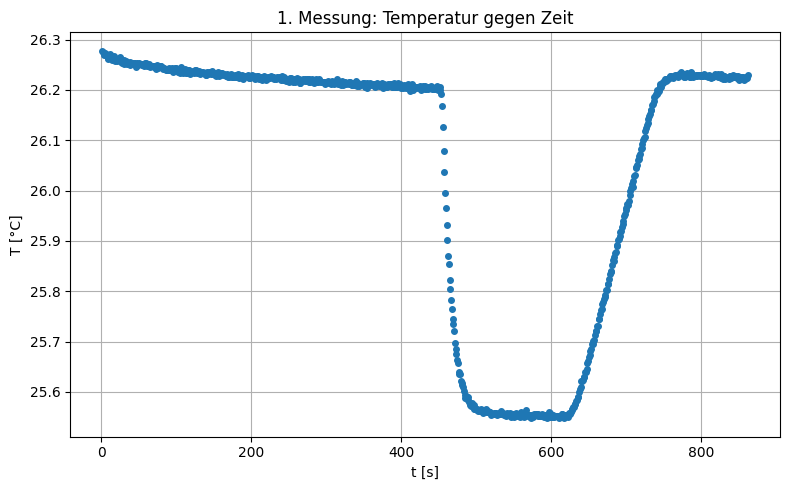

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
xlsx_file = pd.ExcelFile("Kalorimetrie.xlsx", engine="openpyxl")

df = pd.read_excel(
    xlsx_file,
    sheet_name="Tabelle1",
    usecols="A,B",
    skiprows=1,
    nrows=1000
)

# ===============================
# Spalten zuweisen
# ===============================
x = df.iloc[:, 0]  # Spalte A
y = df.iloc[:, 1]  # Spalte B

# ===============================
# Plot erstellen (nur Punkte)
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label="Messdaten", markersize=4)

plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("1. Messung: Temperatur gegen Zeit")
plt.grid(True)
plt.tight_layout()
plt.show()

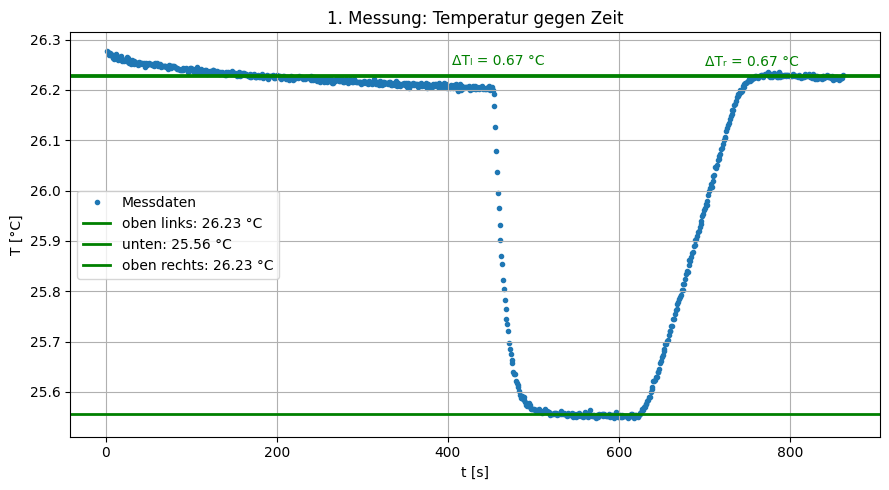

T_oben links  = 26.2302 °C
T_oben rechts = 26.2272 °C
T_unten       = 25.5558 °C
ΔT_links      = 0.6744 °C
ΔT_rechts     = 0.6714 °C


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Kalorimetrie.xlsx", engine="openpyxl",
                   sheet_name="Tabelle1",
                   usecols="A,B",
                   skiprows=1,
                   nrows=1000)

x = df.iloc[:, 0]  # Zeit [s]
y = df.iloc[:, 1]  # Temperatur [°C]

# ===============================
# Zeitbereiche definieren (anpassen!)
# ===============================
# Plateaus links, unten, rechts – manuell nach Bild gewählt:
links_mask  = (x >=  20) & (x <= 350)
unten_mask  = (x >= 500) & (x <= 630)
rechts_mask = (x >= 750) & (x <= 850)

T_links  = y[links_mask].mean()
T_unten  = y[unten_mask].mean()
T_rechts = y[rechts_mask].mean()

# ΔT für linkes und rechtes Plateau
delta_T_links  = T_links - T_unten
delta_T_rechts = T_rechts - T_unten

# ===============================
# Plot
# ===============================
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'o', markersize=3, label="Messdaten", zorder=1)

# Horizontale Linien (Plateaus)
plt.axhline(T_links,  color='green', linestyle='-', linewidth=2, label=f"oben links: {T_links:.2f} °C", zorder=2)
plt.axhline(T_unten,  color='green', linestyle='-', linewidth=2, label=f"unten: {T_unten:.2f} °C", zorder=2)
plt.axhline(T_rechts, color='green', linestyle='-', linewidth=2, label=f"oben rechts: {T_rechts:.2f} °C", zorder=2)

# ΔT anzeigen
plt.text(405, T_links + 0.02, f"ΔTₗ = {delta_T_links:.2f} °C", color='green')
plt.text(700, T_rechts + 0.02, f"ΔTᵣ = {delta_T_rechts:.2f} °C", color='green')

# Achsen und Layout
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("1. Messung: Temperatur gegen Zeit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe
# ===============================
print(f"T_oben links  = {T_links:.4f} °C")
print(f"T_oben rechts = {T_rechts:.4f} °C")
print(f"T_unten       = {T_unten:.4f} °C")
print(f"ΔT_links      = {delta_T_links:.4f} °C")
print(f"ΔT_rechts     = {delta_T_rechts:.4f} °C")

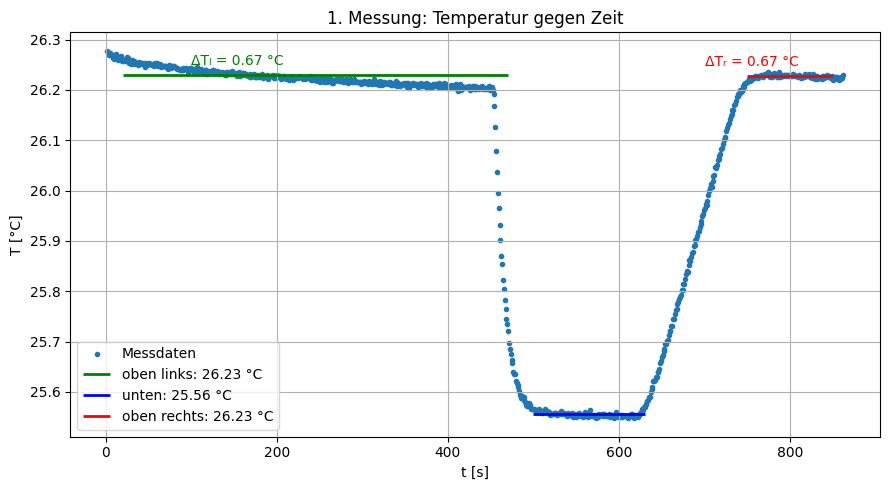

T_oben links  = 26.2302 °C
T_oben rechts = 26.2272 °C
T_unten       = 25.5558 °C
ΔT_links      = 0.6744 °C
ΔT_rechts     = 0.6714 °C


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Kalorimetrie.xlsx", engine="openpyxl",
                   sheet_name="Tabelle1",
                   usecols="A,B",
                   skiprows=1,
                   nrows=1000)

x = df.iloc[:, 0]  # Zeit [s]
y = df.iloc[:, 1]  # Temperatur [°C]

# ===============================
# Zeitbereiche definieren
# ===============================
links_mask  = (x >=  20) & (x <= 350)
unten_mask  = (x >= 500) & (x <= 630)
rechts_mask = (x >= 750) & (x <= 850)

T_links  = y[links_mask].mean()
T_unten  = y[unten_mask].mean()
T_rechts = y[rechts_mask].mean()

# ΔT
delta_T_links  = T_links - T_unten
delta_T_rechts = T_rechts - T_unten

# ===============================
# Plot
# ===============================
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'o', markersize=3, label="Messdaten", zorder=1)

# Horizontale Linien getrennt zeichnen:
plt.hlines(T_links,  xmin=20,  xmax=470,  color='green', linewidth=2, label=f"oben links: {T_links:.2f} °C")
plt.hlines(T_unten,  xmin=500, xmax=630,  color='blue',  linewidth=2, label=f"unten: {T_unten:.2f} °C")
plt.hlines(T_rechts, xmin=750, xmax=850,  color='red',   linewidth=2, label=f"oben rechts: {T_rechts:.2f} °C")

# ΔT anzeigen
plt.text(100, T_links + 0.02, f"ΔTₗ = {delta_T_links:.2f} °C", color='green')
plt.text(700, T_rechts + 0.02, f"ΔTᵣ = {delta_T_rechts:.2f} °C", color='red')

# Achsen & Layout
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("1. Messung: Temperatur gegen Zeit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe
# ===============================
print(f"T_oben links  = {T_links:.4f} °C")
print(f"T_oben rechts = {T_rechts:.4f} °C")
print(f"T_unten       = {T_unten:.4f} °C")
print(f"ΔT_links      = {delta_T_links:.4f} °C")
print(f"ΔT_rechts     = {delta_T_rechts:.4f} °C")

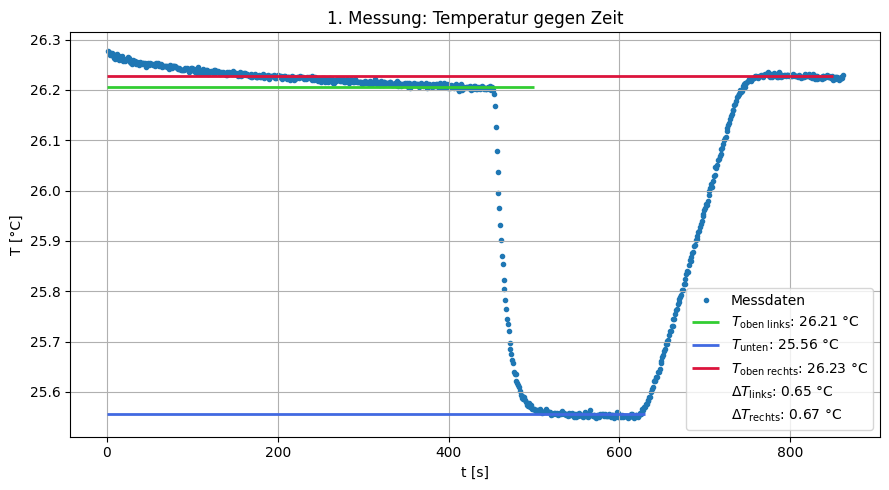

T_oben links  = 26.2061 °C
T_unten       = 25.5558 °C
T_oben rechts = 26.2272 °C
ΔT_links      = 0.6504 °C
ΔT_rechts     = 0.6714 °C


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Kalorimetrie.xlsx", engine="openpyxl",
                   sheet_name="Tabelle1",
                   usecols="A,B",
                   skiprows=1,
                   nrows=1000)

x = df.iloc[:, 0]  # Zeit [s]
y = df.iloc[:, 1]  # Temperatur [°C]

# ===============================
# Zeitbereiche definieren
# ===============================
links_mask  = (x >= 390) & (x <= 430)  # neuer Bereich: näher am Sprung
unten_mask  = (x >= 500) & (x <= 630)
rechts_mask = (x >= 750) & (x <= 850)

T_links  = y[links_mask].mean()
T_unten  = y[unten_mask].mean()
T_rechts = y[rechts_mask].mean()

# ΔT
delta_T_links  = T_links - T_unten
delta_T_rechts = T_rechts - T_unten

# ===============================
# Plot
# ===============================
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'o', markersize=3, label="Messdaten", zorder=1)

# Horizontale Linien für die drei Plateaus
# Horizontale Linien mit T-Werten
# Horizontale Linien mit T-Werten
# Horizontale Linien mit T-Werten
plt.hlines(T_links,  xmin=0, xmax=500,  color='limegreen', linewidth=2,
           label=fr"$T_{{\mathrm{{oben\ links}}}}$: {T_links:.2f} °C")

plt.hlines(T_unten,  xmin=0, xmax=630,  color='royalblue', linewidth=2,
           label=fr"$T_{{\mathrm{{unten}}}}$: {T_unten:.2f} °C")

plt.hlines(T_rechts, xmin=0, xmax=850,  color='crimson', linewidth=2,
           label=fr"$T_{{\mathrm{{oben\ rechts}}}}$: {T_rechts:.2f} °C")

# ΔT in die Legende – mit Index
plt.plot([], [], ' ', label=fr"$\Delta T_{{\mathrm{{links}}}}$: {delta_T_links:.2f} °C")
plt.plot([], [], ' ', label=fr"$\Delta T_{{\mathrm{{rechts}}}}$: {delta_T_rechts:.2f} °C")

# Achsen & Layout
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("1. Messung: Temperatur gegen Zeit")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ===============================
# Werte ausgeben
# ===============================
print(f"T_oben links  = {T_links:.4f} °C")
print(f"T_unten       = {T_unten:.4f} °C")
print(f"T_oben rechts = {T_rechts:.4f} °C")
print(f"ΔT_links      = {delta_T_links:.4f} °C")
print(f"ΔT_rechts     = {delta_T_rechts:.4f} °C")

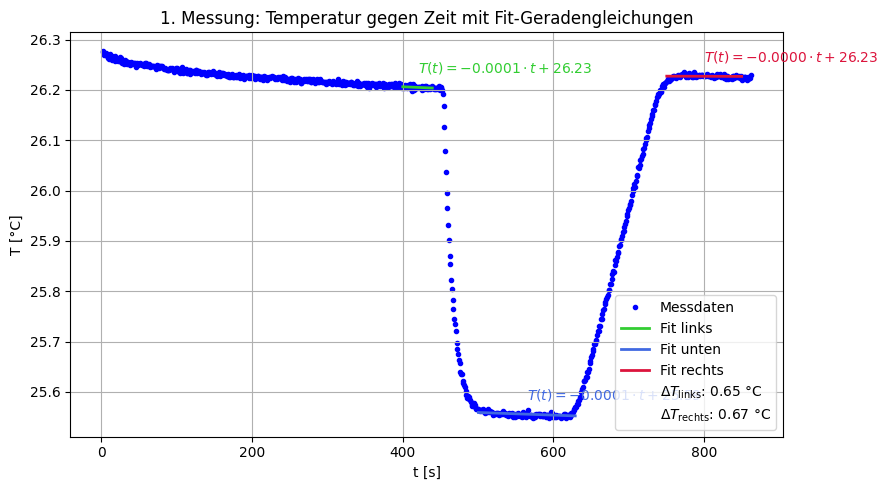

Gerade links:     T(t) = -0.0001 * t + 26.23
Gerade unten:     T(t) = -0.0001 * t + 25.59
Gerade rechts:    T(t) = -0.0000 * t + 26.23

ΔT_links  = 0.6515 °C
ΔT_rechts = 0.6746 °C


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Kalorimetrie.xlsx", engine="openpyxl",
                   sheet_name="Tabelle1",
                   usecols="A,B",
                   skiprows=1,
                   nrows=1000)

x = df.iloc[:, 0]  # Zeit [s]
y = df.iloc[:, 1]  # Temperatur [°C]

# ===============================
# Zeitbereiche definieren
# ===============================
links_mask  = (x >= 400) & (x <= 440)
unten_mask  = (x >= 500) & (x <= 630)
rechts_mask = (x >= 750) & (x <= 850)

# Daten extrahieren
x_links,  y_links  = x[links_mask],  y[links_mask]
x_unten,  y_unten  = x[unten_mask],  y[unten_mask]
x_rechts, y_rechts = x[rechts_mask], y[rechts_mask]

# ===============================
# Lineare Fits durchführen
# ===============================
slope_l, intercept_l, *_ = linregress(x_links, y_links)
slope_u, intercept_u, *_ = linregress(x_unten, y_unten)
slope_r, intercept_r, *_ = linregress(x_rechts, y_rechts)

# Fitkurven berechnen
x_fit_l = np.linspace(x_links.min(), x_links.max(), 100)
x_fit_u = np.linspace(x_unten.min(), x_unten.max(), 100)
x_fit_r = np.linspace(x_rechts.min(), x_rechts.max(), 100)

y_fit_l = slope_l * x_fit_l + intercept_l
y_fit_u = slope_u * x_fit_u + intercept_u
y_fit_r = slope_r * x_fit_r + intercept_r

# ΔT aus Fit-Endpunkten
delta_T_links  = (slope_l * x_fit_l[-1] + intercept_l) - (slope_u * x_fit_u[-1] + intercept_u)
delta_T_rechts = (slope_r * x_fit_r[-1] + intercept_r) - (slope_u * x_fit_u[-1] + intercept_u)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'o', markersize=3, color='blue', label="Messdaten", zorder=1)

# Fit-Geraden plotten
plt.plot(x_fit_l, y_fit_l, color='limegreen', linewidth=2, label="Fit links")
plt.plot(x_fit_u, y_fit_u, color='royalblue', linewidth=2, label="Fit unten")
plt.plot(x_fit_r, y_fit_r, color='crimson', linewidth=2, label="Fit rechts")

# Geradengleichungen direkt im Plot anzeigen
plt.text(x_fit_l.mean(), y_fit_l.mean() + 0.03,
         fr"$T(t) = {slope_l:.4f} \cdot t + {intercept_l:.2f}$",
         color='limegreen')
plt.text(x_fit_u.mean(), y_fit_u.mean() + 0.03,
         fr"$T(t) = {slope_u:.4f} \cdot t + {intercept_u:.2f}$",
         color='royalblue')
plt.text(x_fit_r.mean(), y_fit_r.mean() + 0.03,
         fr"$T(t) = {slope_r:.4f} \cdot t + {intercept_r:.2f}$",
         color='crimson')

# ΔT-Werte in Legende
plt.plot([], [], ' ', label=fr"$\Delta T_{{\mathrm{{links}}}}$: {delta_T_links:.2f} °C")
plt.plot([], [], ' ', label=fr"$\Delta T_{{\mathrm{{rechts}}}}$: {delta_T_rechts:.2f} °C")

# Achsen & Layout
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("1. Messung: Temperatur gegen Zeit mit Fit-Geradengleichungen")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe
# ===============================
print(f"Gerade links:     T(t) = {slope_l:.4f} * t + {intercept_l:.2f}")
print(f"Gerade unten:     T(t) = {slope_u:.4f} * t + {intercept_u:.2f}")
print(f"Gerade rechts:    T(t) = {slope_r:.4f} * t + {intercept_r:.2f}")
print()
print(f"ΔT_links  = {delta_T_links:.4f} °C")
print(f"ΔT_rechts = {delta_T_rechts:.4f} °C")

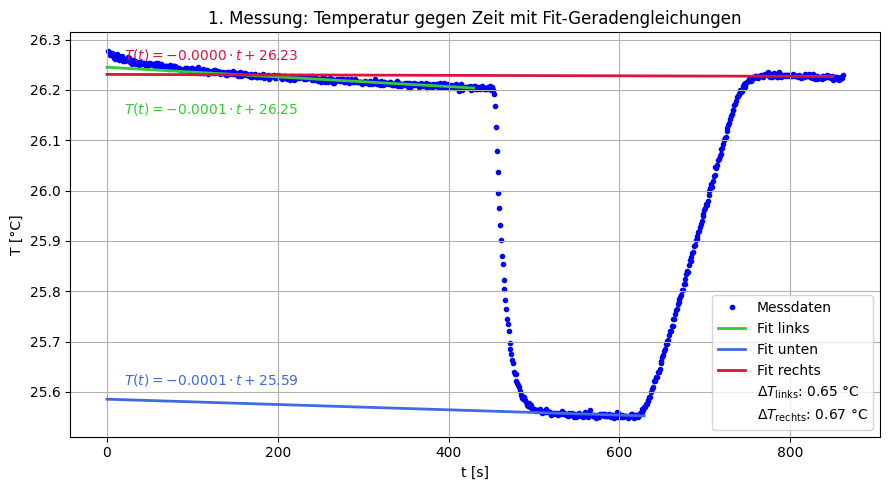

Gerade links:     T(t) = -0.0001 * t + 26.25
Gerade unten:     T(t) = -0.0001 * t + 25.59
Gerade rechts:    T(t) = -0.0000 * t + 26.23

ΔT_links  = 0.6516 °C
ΔT_rechts = 0.6746 °C


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Kalorimetrie.xlsx", engine="openpyxl",
                   sheet_name="Tabelle1",
                   usecols="A,B",
                   skiprows=1,
                   nrows=1000)

x = df.iloc[:, 0]  # Zeit [s]
y = df.iloc[:, 1]  # Temperatur [°C]

# ===============================
# Zeitbereiche definieren
# ===============================
links_mask  = (x >= 400) & (x <= 430)
unten_mask  = (x >= 500) & (x <= 630)
rechts_mask = (x >= 750) & (x <= 850)

# Daten extrahieren
x_links,  y_links  = x[links_mask],  y[links_mask]
x_unten,  y_unten  = x[unten_mask],  y[unten_mask]
x_rechts, y_rechts = x[rechts_mask], y[rechts_mask]

# ===============================
# Lineare Fits durchführen
# ===============================
slope_l, intercept_l, *_ = linregress(x_links, y_links)
slope_u, intercept_u, *_ = linregress(x_unten, y_unten)
slope_r, intercept_r, *_ = linregress(x_rechts, y_rechts)

# Fitkurven berechnen – alle ab t = 0
x_fit_l = np.linspace(0, x_links.max(), 200)
x_fit_u = np.linspace(0, x_unten.max(), 200)
x_fit_r = np.linspace(0, x_rechts.max(), 200)

y_fit_l = slope_l * x_fit_l + intercept_l
y_fit_u = slope_u * x_fit_u + intercept_u
y_fit_r = slope_r * x_fit_r + intercept_r

# ΔT aus Fit-Endpunkten
delta_T_links  = (slope_l * x_fit_l[-1] + intercept_l) - (slope_u * x_fit_u[-1] + intercept_u)
delta_T_rechts = (slope_r * x_fit_r[-1] + intercept_r) - (slope_u * x_fit_u[-1] + intercept_u)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'o', markersize=3, color='blue', label="Messdaten", zorder=1)

# Fit-Geraden plotten
plt.plot(x_fit_l, y_fit_l, color='limegreen', linewidth=2, label="Fit links")
plt.plot(x_fit_u, y_fit_u, color='royalblue', linewidth=2, label="Fit unten")
plt.plot(x_fit_r, y_fit_r, color='crimson', linewidth=2, label="Fit rechts")

# Geradengleichungen direkt ins Diagramm schreiben
plt.text(20, slope_l * 20 + intercept_l + -0.09,
         fr"$T(t) = {slope_l:.4f} \cdot t + {intercept_l:.2f}$", color='limegreen')
plt.text(20, slope_u * 20 + intercept_u + 0.03,
         fr"$T(t) = {slope_u:.4f} \cdot t + {intercept_u:.2f}$", color='royalblue')
plt.text(20, slope_r * 20 + intercept_r + 0.03,
         fr"$T(t) = {slope_r:.4f} \cdot t + {intercept_r:.2f}$", color='crimson')

# ΔT-Werte in Legende
plt.plot([], [], ' ', label=fr"$\Delta T_{{\mathrm{{links}}}}$: {delta_T_links:.2f} °C")
plt.plot([], [], ' ', label=fr"$\Delta T_{{\mathrm{{rechts}}}}$: {delta_T_rechts:.2f} °C")

# Achsen & Layout
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("1. Messung: Temperatur gegen Zeit mit Fit-Geradengleichungen")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ===============================
# Konsole-Ausgabe
# ===============================
print(f"Gerade links:     T(t) = {slope_l:.4f} * t + {intercept_l:.2f}")
print(f"Gerade unten:     T(t) = {slope_u:.4f} * t + {intercept_u:.2f}")
print(f"Gerade rechts:    T(t) = {slope_r:.4f} * t + {intercept_r:.2f}")
print()
print(f"ΔT_links  = {delta_T_links:.4f} °C")
print(f"ΔT_rechts = {delta_T_rechts:.4f} °C")